Ajan kar zarar grafiği

In [ ]:
!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

import random

In [23]:
#  MarketAgent Sınıfı



class MarketAgent(mesa.Agent):
    def __init__(self,model, sermaye):
        super().__init__(model)


    def step(self):
        pass



In [24]:
import matplotlib.pyplot as plt
from mesa.datacollection import DataCollector
import random
class StonkModel(mesa.Model):
    def __init__(self):
        self.value = 300  # Başlangıç hisse değeri
        self.profit = None  # Kar/Zarar bilgisi
        self.datacollector = DataCollector(
            model_reporters={"Stock Value": "value", "Profit": "profit"}
        )

    def step(self):
        import random
        price_change = random.gauss(10, 100)  # Normal dağılıma göre fiyat değişimi
        new_value = self.value + price_change

        if new_value < self.value:
            self.profit = False  # Kırmızı (Zarar)
        else:
            self.profit = True  # Yeşil (Kar)

        self.value = max(0, new_value)  # Değer sıfırın altına inemez
        self.datacollector.collect(self)




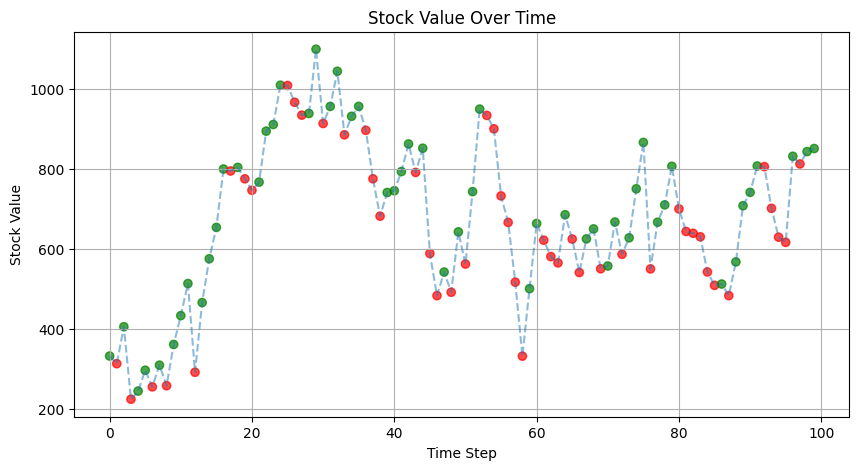

In [25]:
# Modeli çalıştırma ve verileri toplama
model = StonkModel()
values = []
profits = []

for i in range(100):  # 100 adım simüle et
    model.step()
    values.append(model.value)
    profits.append(model.profit)

# Veriyi çizme
colors = ['green' if p else 'red' for p in profits]
plt.figure(figsize=(10, 5))
plt.scatter(range(100), values, c=colors, alpha=0.7)
plt.plot(values, linestyle='dashed', alpha=0.5)
plt.title("Stock Value Over Time")
plt.xlabel("Time Step")
plt.ylabel("Stock Value")
plt.grid()
plt.show()

In [28]:

from mesa.datacollection import DataCollector


class TraderAgent(mesa.Agent):
    def __init__(self,model):
        super().__init__(model)
        self.value = 300  # Başlangıç hisse fiyatı
        self.held = []  # Tutulan hisseler (alış fiyatı, miktar)
        self.total_held = 0  # Toplam hisse miktarı
        self.profit = 0  # Kâr/Zarar
        self.sell_profit = None

    def step(self):
        self.update_stock_price()

    def update_stock_price(self):
        import random
        to_add = int(random.gauss(10, 100 * self.model.market_volatility))
        if random.random() <= 0.5:
            self.value = max(0, self.value - to_add)  # Değer sıfırın altına inemez
        else:
            self.value += to_add

    def buy(self, amount):
        self.held.append((self.value, amount))
        self.total_held += amount

    def sell(self, amount):
        if amount > self.total_held:
            amount = self.total_held
        internal_sell_amount = amount

        while internal_sell_amount > 0 and self.held:
            bought_price, volume = self.held[0]
            profit_diff = volume * (self.value - bought_price)
            self.sell_profit = profit_diff >= 0
            self.profit += profit_diff

            if volume > internal_sell_amount:
                self.held[0] = (bought_price, volume - internal_sell_amount)
                internal_sell_amount = 0
            else:
                self.held.pop(0)
                internal_sell_amount -= volume

        self.total_held -= amount

class StonkModel(mesa.Model):
    def __init__(self, num_agents=10, market_volatility=0.1):
        super().__init__()
        self.num_agents = num_agents
        self.market_volatility = market_volatility


        for i in range(num_agents):
            agent = TraderAgent(self)
            self.agents.add(agent)

        self.datacollector = DataCollector(
            model_reporters={"Stock Price": lambda m: m.agents[0].value,
                             "Profit": lambda m: m.agents[0].profit}
        )

    def step(self):
        self.datacollector.collect(self)
        self.agents.do("step")

# Modeli çalıştırma örneği
model = StonkModel()
for i in range(100):
    model.step()

data = model.datacollector.get_model_vars_dataframe()
print(data)


    Stock Price  Profit
0           300       0
1           307       0
2           291       0
3           284       0
4           287       0
..          ...     ...
95          438       0
96          420       0
97          413       0
98          397       0
99          401       0

[100 rows x 2 columns]
